In [ ]:
import numpy as np
import cv2 #import OpenCV
import matplotlib.pyplot as plt
from skimage.filters.rank import entropy
from skimage.morphology import disk
import fnmatch
import os

In [ ]:


workingpath="/home/cyril/liora/projet"
normal_files="/COVID-19_Radiography_Dataset/Normal"
covid_files="/COVID-19_Radiography_Dataset/COVID"
lungOpacity_files="/COVID-19_Radiography_Dataset/Lung_Opacity"
viralPneumonia_files="/COVID-19_Radiography_Dataset/Viral Pneumonia"
size_img=299
size_small_img=50

# read normal images and their masks, apply the masks to the images, resize them and stock them in a 3D array
nb_files_Normal=len(fnmatch.filter(os.listdir(workingpath+normal_files+"/images/"), "*.png"))
all_img_Normal = np.zeros((size_img, size_img, nb_files_Normal),  dtype=np.uint8)
all_img_Normal_without_mask = np.zeros((size_img, size_img, nb_files_Normal),  dtype=np.uint8)
all_small_Normal = np.zeros((size_small_img, size_small_img, nb_files_Normal),  dtype=np.uint8)
all_masks_Normal = np.zeros((size_img, size_img, nb_files_Normal),  dtype=np.uint8)
for i in range(0, nb_files_Normal):
    img_Normal = cv2.imread(workingpath+normal_files +"/images/Normal-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE)  

    img_Normal_mask = cv2.imread(workingpath+normal_files +"/masks/Normal-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE) # pour lire

    img_mask_resized = cv2.resize(img_Normal_mask, (img_Normal.shape[0], img_Normal.shape[1]), 0, 0, cv2.INTER_NEAREST)
    img_Normal_and_mask = cv2.bitwise_and(img_Normal,img_mask_resized)
    img_Normal_and_mask_resized = cv2.resize(img_Normal_and_mask, (size_img, size_img), 0, 0, cv2.INTER_NEAREST)
    all_masks_Normal[:,:,i] = img_mask_resized
    all_img_Normal[:,:,i] = img_Normal_and_mask_resized
    all_small_Normal[:,:,i] = cv2.resize(img_Normal_and_mask_resized, (size_small_img, size_small_img), 0, 0, cv2.INTER_NEAREST)
    all_img_Normal_without_mask[:,:,i]=img_Normal








In [ ]:
# read covid images and their masks, apply the masks to the images, resize them and stock them in a 3D array
nb_files_Covid=len(fnmatch.filter(os.listdir(workingpath+covid_files+"/images/"), "*.png"))
all_img_Covid = np.zeros((size_img, size_img, nb_files_Covid),  dtype=np.uint8)
all_small_Covid = np.zeros((size_small_img, size_small_img, nb_files_Covid),  dtype=np.uint8)
all_masks_Covid = np.zeros((size_img, size_img, nb_files_Covid),  dtype=np.uint8)
all_img_Covid_without_mask= np.zeros((size_img, size_img, nb_files_Covid),  dtype=np.uint8)
for i in range(0, nb_files_Covid):
    img_Covid = cv2.imread(workingpath+covid_files +"/images/COVID-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE)  

    img_Covid_mask = cv2.imread(workingpath+covid_files +"/masks/COVID-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE) # pour lire

    img_mask_resized = cv2.resize(img_Covid_mask, (img_Covid.shape[0], img_Covid.shape[1]), 0, 0, cv2.INTER_NEAREST)
    img_Covid_and_mask = cv2.bitwise_and(img_Covid,img_mask_resized)
    img_Covid_and_mask_resized = cv2.resize(img_Covid_and_mask, (size_img, size_img), 0, 0, cv2.INTER_NEAREST)
    all_masks_Covid[:,:,i] = img_mask_resized
    all_img_Covid[:,:,i] = img_Covid_and_mask_resized
    all_small_Covid[:,:,i] = cv2.resize(img_Covid_and_mask_resized, (size_small_img, size_small_img), 0, 0, cv2.INTER_NEAREST)
    all_img_Covid_without_mask[:,:,i]=img_Covid
    

In [ ]:
# read lung opacity images and their masks, apply the masks to the images, resize them and stock them in a 3D array
nb_files_LungOpacity=len(fnmatch.filter(os.listdir(workingpath+lungOpacity_files+"/images/"), "*.png"))
all_img_LungOpacity = np.zeros((size_img, size_img, nb_files_LungOpacity),  dtype=np.uint8)
all_small_LungOpacity = np.zeros((size_small_img, size_small_img, nb_files_LungOpacity),  dtype=np.uint8)
all_masks_LungOpacity = np.zeros((size_img, size_img, nb_files_LungOpacity),  dtype=np.uint8)
all_img_LungOpacity_without_mask = np.zeros((size_img, size_img, nb_files_LungOpacity),  dtype=np.uint8)
for i in range(0, nb_files_LungOpacity):
    img_LungOpacity = cv2.imread(workingpath+lungOpacity_files +"/images/Lung_Opacity-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE)  

    img_LungOpacity_mask = cv2.imread(workingpath+lungOpacity_files +"/masks/Lung_Opacity-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE) # pour lire

    img_mask_resized = cv2.resize(img_LungOpacity_mask, (img_LungOpacity.shape[0], img_LungOpacity.shape[1]), 0, 0, cv2.INTER_NEAREST)
    img_LungOpacity_and_mask = cv2.bitwise_and(img_LungOpacity,img_mask_resized)
    img_LungOpacity_and_mask_resized = cv2.resize(img_LungOpacity_and_mask, (size_img, size_img), 0, 0, cv2.INTER_NEAREST)
    all_masks_LungOpacity[:,:,i] = img_mask_resized
    all_img_LungOpacity[:,:,i] = img_LungOpacity_and_mask_resized
    all_small_LungOpacity[:,:,i] = cv2.resize(img_LungOpacity_and_mask_resized, (size_small_img, size_small_img), 0, 0, cv2.INTER_NEAREST)
    all_img_LungOpacity_without_mask[:,:,i]=img_LungOpacity

In [ ]:
# read viral pneumonia images and their masks, apply the masks to the images, resize them and stock them in a 3D array
nb_files_ViralPneumonia=len(fnmatch.filter(os.listdir(workingpath+viralPneumonia_files+"/images/"), "*.png"))
all_img_ViralPneumonia = np.zeros((size_img, size_img, nb_files_ViralPneumonia),  dtype=np.uint8)
all_small_ViralPneumonia = np.zeros((size_small_img, size_small_img, nb_files_ViralPneumonia),  dtype=np.uint8)
all_masks_ViralPneumonia= np.zeros((size_img, size_img, nb_files_ViralPneumonia),  dtype=np.uint8)
all_img_ViralPneumonia_without_mask = np.zeros((size_img, size_img, nb_files_ViralPneumonia),  dtype=np.uint8)
for i in range(0, nb_files_ViralPneumonia):
    img_ViralPneumonia = cv2.imread(workingpath+viralPneumonia_files +"/images/Viral Pneumonia-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE)  

    img_ViralPneumonia_mask = cv2.imread(workingpath+viralPneumonia_files +"/masks/Viral Pneumonia-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE) # pour lire

    img_mask_resized = cv2.resize(img_ViralPneumonia_mask, (img_ViralPneumonia.shape[0], img_ViralPneumonia.shape[1]), 0, 0, cv2.INTER_NEAREST)
    img_ViralPneumonia_and_mask = cv2.bitwise_and(img_ViralPneumonia,img_mask_resized)
    img_ViralPneumonia_and_mask_resized = cv2.resize(img_ViralPneumonia_and_mask, (size_img, size_img), 0, 0, cv2.INTER_NEAREST)
    all_masks_ViralPneumonia[:,:,i] = img_mask_resized
    all_img_ViralPneumonia[:,:,i] = img_ViralPneumonia_and_mask_resized
    all_small_ViralPneumonia[:,:,i] = cv2.resize(img_ViralPneumonia_and_mask_resized, (size_small_img, size_small_img), 0, 0, cv2.INTER_NEAREST)
    all_img_ViralPneumonia_without_mask[:,:,i]=img_ViralPneumonia

In [ ]:
print('nb_files_Normal:', all_img_Normal.shape[2])
print('nb_files_Covid:', all_img_Covid.shape[2])
print('nb_files_LungOpacity:', all_img_LungOpacity.shape[2])
print('nb_files_ViralPneumonia:', all_img_ViralPneumonia.shape[2])


nb_files_Normal: 10192
nb_files_Covid: 3616
nb_files_LungOpacity: 6012
nb_files_ViralPneumonia: 1345


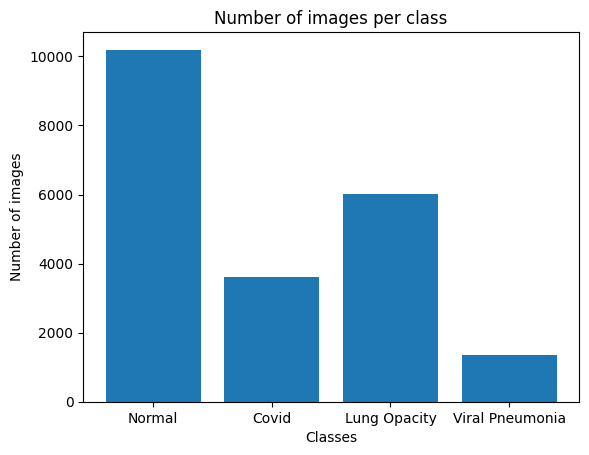

In [ ]:
plt.bar([0, 1, 2, 3], [all_img_Normal.shape[2], all_img_Covid.shape[2], all_img_LungOpacity.shape[2], all_img_ViralPneumonia.shape[2]])
plt.xlabel('Classes')
plt.ylabel('Number of images')
plt.title('Number of images per class')
plt.xticks([0, 1, 2, 3], ['Normal', 'Covid', 'Lung Opacity', 'Viral Pneumonia'])
plt.show()

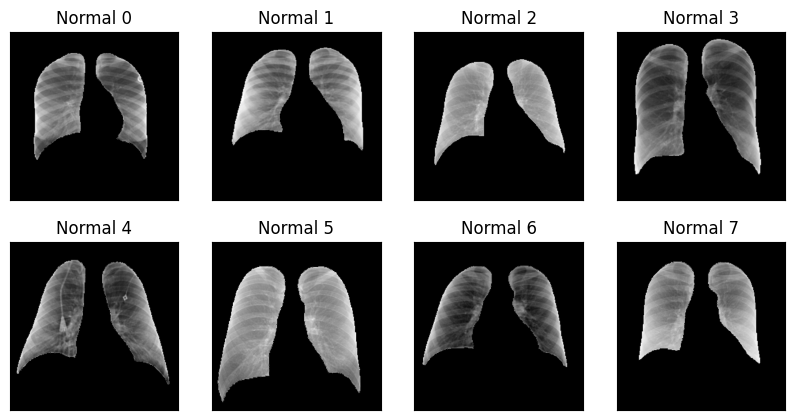

In [ ]:

rows = 2
columns = 4
fig =  plt.figure(figsize = (10,5))

for i in range(0, rows*columns):
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_Normal[:,:,i], cmap='gray');
    plt.xticks([]);
    plt.yticks([]);
    plt.title("Normal "+str(i))
    

Text(0.5, 1.0, 'mean of all normal images')

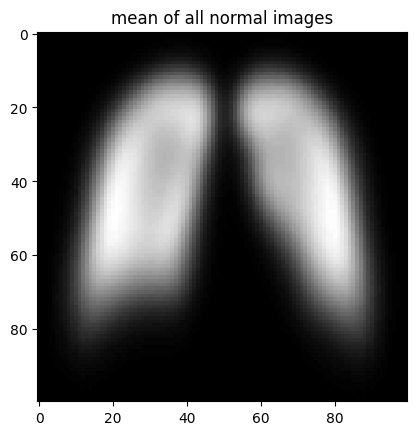

In [ ]:
normalmean=np.mean(all_small_Normal, axis=2).astype("uint8")
plt.imshow(normalmean, cmap='gray');
plt.title("mean of all normal images")

Text(0.5, 1.0, 'median of all normal images')

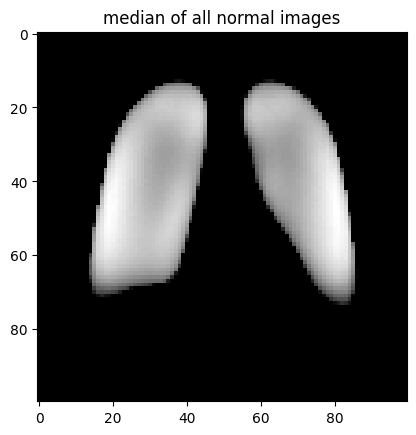

In [ ]:
normalmedian=np.median(all_small_Normal, axis=2).astype("uint8")
plt.imshow(normalmedian, cmap='gray');
plt.title("median of all normal images")


In [ ]:
def mse(imageA, imageB):
   
    assert imageA.shape == imageB.shape, "Images must be the same size."
  
    err = np.sum((imageA.astype("float") - imageB.astype("float")) ** 2)
    err /= float(imageA.shape[0] * imageA.shape[1])

    return err


all_normal_mse=[]
for i in range(0, nb_files_Normal):
    
    diff= mse(normalmean, all_small_Normal[:,:,i])
    all_normal_mse.append(diff)



Text(0.5, 1.0, 'mse between each normal image and the mean of all normal images')

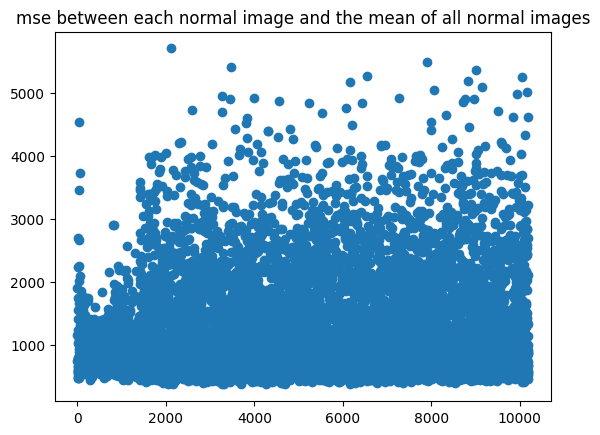

In [ ]:
#print(len(all_normal_mse))
plt.scatter(range(0, len(all_normal_mse)), all_normal_mse)
plt.title("mse between each normal image and the mean of all normal images")

In [ ]:
all_normal_mse_arr = np.array(all_normal_mse)
values_outliers_normal=np.where(all_normal_mse_arr > 5000)[0]
print("indices éloignés:",values_outliers_normal)





indices éloignés: [ 2106  3468  6165  6546  7905  8063  8821  9001  9143 10046 10155]


In [ ]:

values_proche_normal=np.where(all_normal_mse_arr<400)[0]
print("indices proche :",values_proche_normal)


indices proche : [1938 2055 2150 3278 3308 3707 4273 4624 4684 6157]


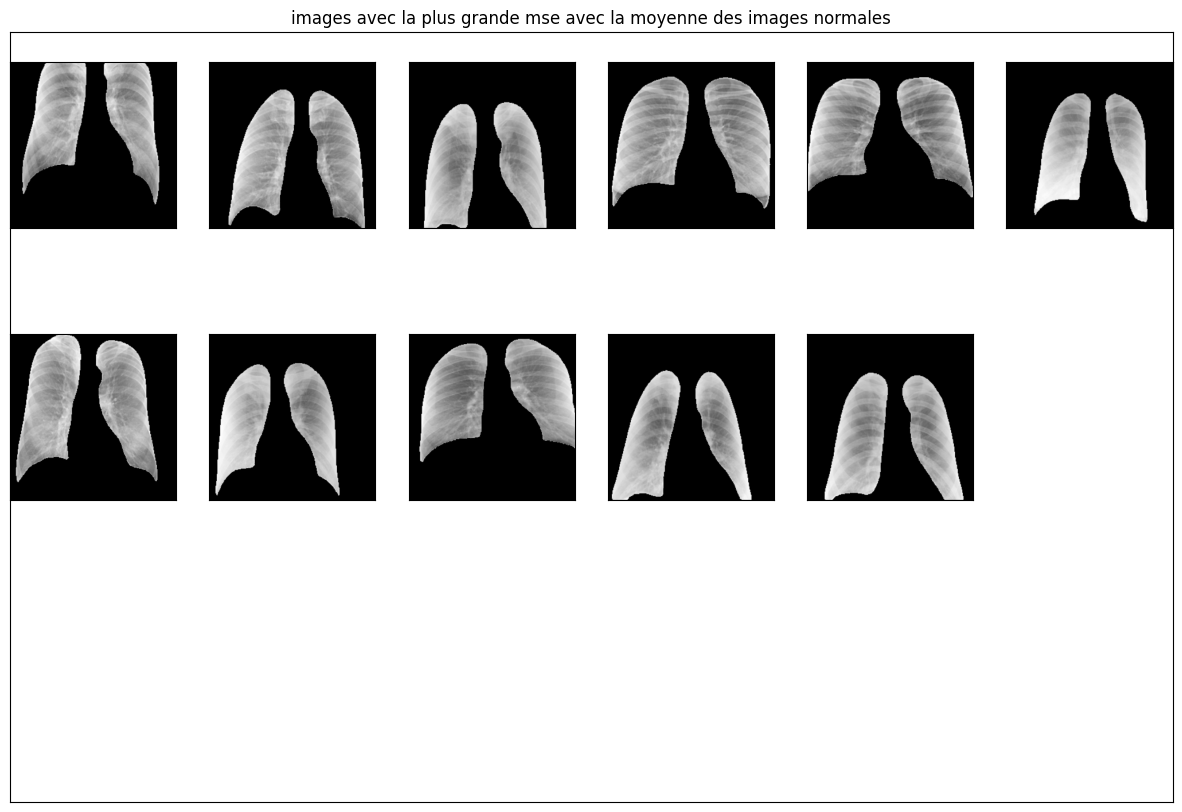

In [ ]:
fig =  plt.figure(figsize = (15,10))
plt.title("images avec la plus grande mse avec la moyenne des images normales")
plt.xticks([]);
plt.yticks([]);
columns = 6
rows = len(values_outliers_normal)//4+1
j=1

for i in values_outliers_normal :
    fig.add_subplot(rows, columns, j)
    plt.imshow(all_img_Normal_without_mask[:,:,i], cmap='gray');
    plt.xticks([]);
    plt.yticks([]);
    j=j+1




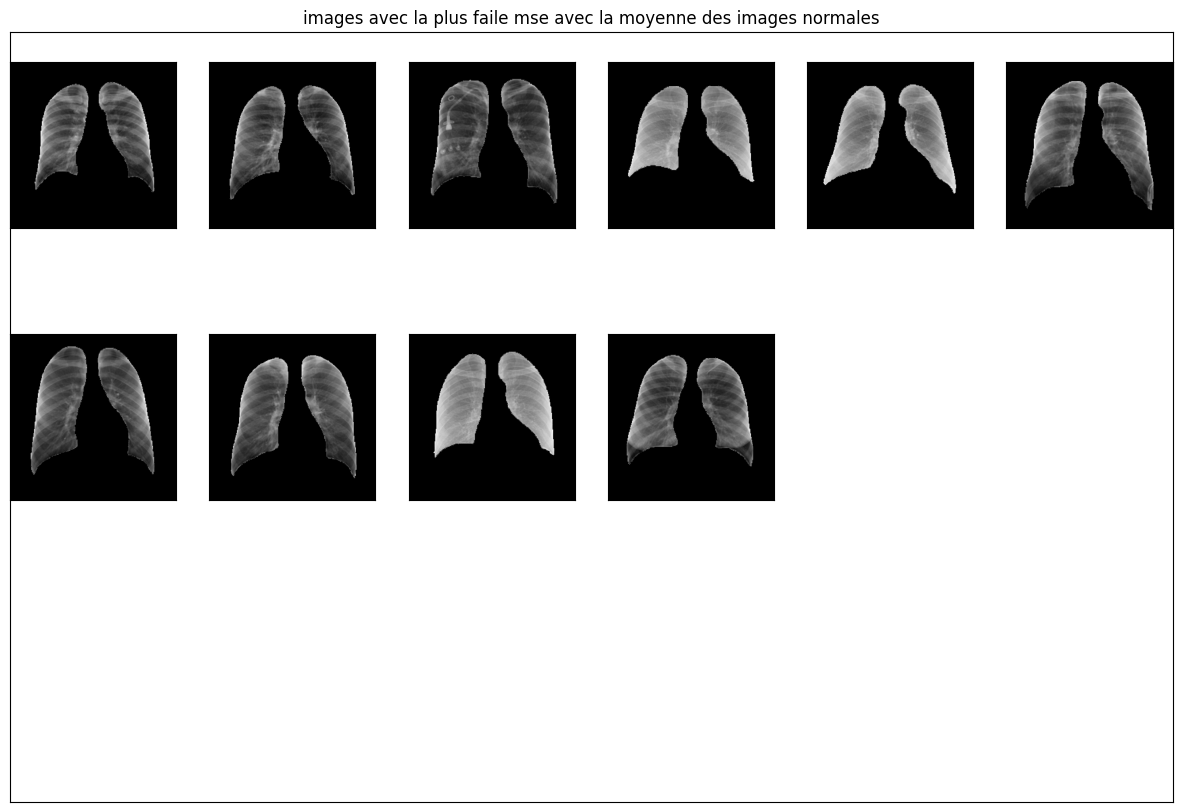

In [ ]:
fig =  plt.figure(figsize = (15,10))
plt.title("images avec la plus faile mse avec la moyenne des images normales")
plt.xticks([]);
plt.yticks([]);
columns = 6
rows = len(values_proche_normal)//4+1
j=1

for i in values_proche_normal :
    fig.add_subplot(rows, columns, j)
    plt.imshow(all_img_Normal_without_mask[:,:,i], cmap='gray');
    plt.xticks([]);
    plt.yticks([]);
    j=j+1


In [ ]:
####### FIN NORMAL et DEBUT COVID ########

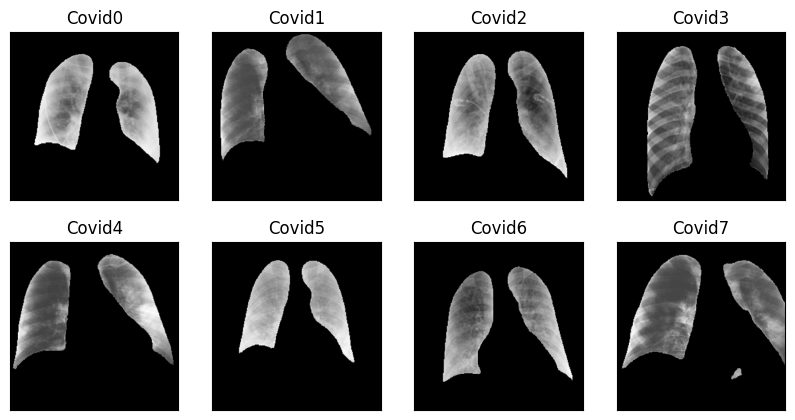

In [ ]:
rows = 2
columns = 4
fig =  plt.figure(figsize = (10,5))

for i in range(0, rows*columns):
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_Covid[:,:,i], cmap='gray');
    plt.xticks([]);
    plt.yticks([]);
    plt.title("Covid"+str(i))

Text(0.5, 1.0, 'mean of all covid images')

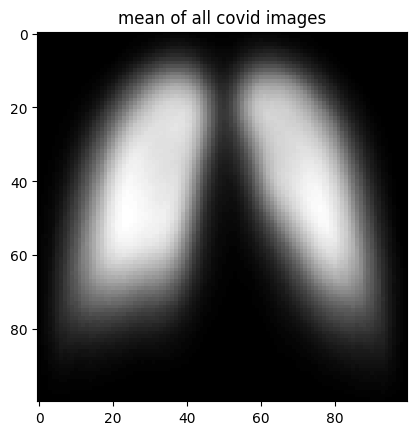

In [ ]:
covidmean=np.mean(all_small_Covid, axis=2).astype("uint8")
plt.imshow(covidmean, cmap='gray');
plt.title("mean of all covid images")

Text(0.5, 1.0, 'median of all covid images')

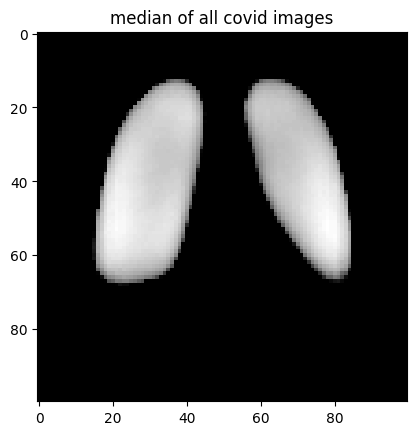

In [ ]:
covidmedian=np.median(all_small_Covid, axis=2).astype("uint8")
plt.imshow(covidmedian, cmap='gray');
plt.title("median of all covid images")

In [ ]:
all_covid_mse=[]
for i in range(0, nb_files_Covid):
    
    diff= mse(covidmean, all_small_Covid[:,:,i])
    all_covid_mse.append(diff)

700.283


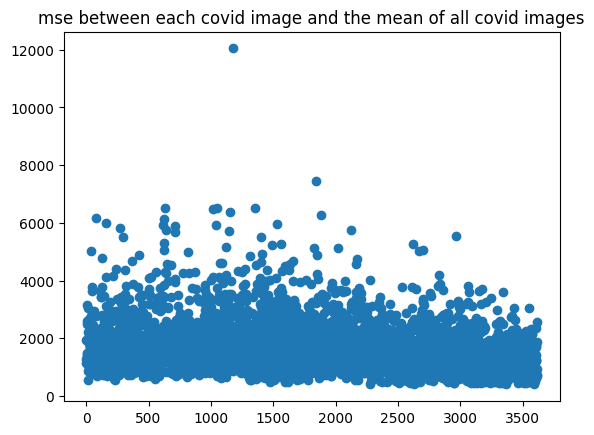

In [ ]:
plt.scatter(range(0, len(all_covid_mse)), all_covid_mse)
plt.title("mse between each covid image and the mean of all covid images")

print(all_covid_mse[3615])

In [ ]:
all_covid_mse_arr = np.array(all_covid_mse)
mask = all_covid_mse_arr > 5000
values_outliers_covid=np.where(mask)[0]
print("indices:",values_outliers_covid)



indices: [  38   76  162  269  296  618  621  623  624  635  638  709  711 1016
 1045 1048 1123 1147 1155 1178 1356 1401 1490 1534 1564 1826 1842 1880
 2017 2120 2617 2671 2704 2962]


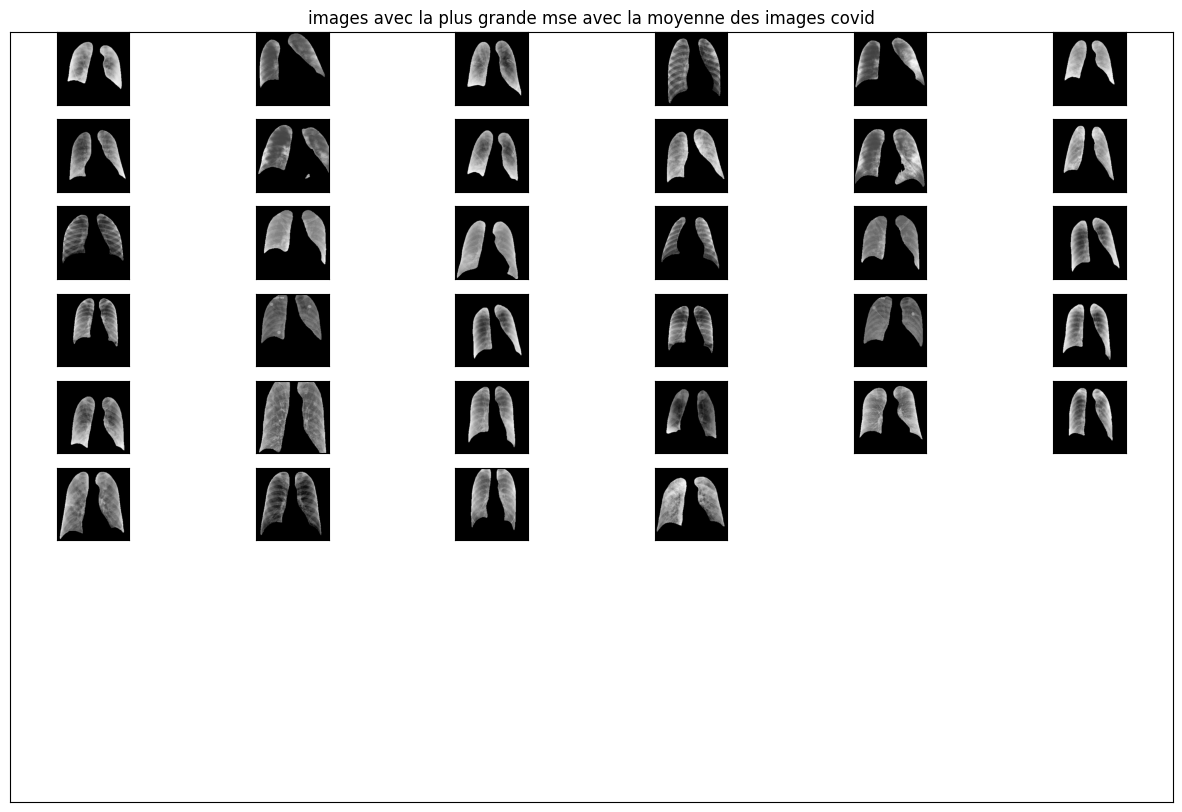

In [ ]:
fig =  plt.figure(figsize = (15,10))
plt.title("images avec la plus grande mse avec la moyenne des images covid")
plt.xticks([]);
plt.yticks([]);
columns = 6
rows = len(values_outliers_covid)//4+1

for i in range(0, len(values_outliers_covid)):
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_Covid[:,:,i], cmap='gray');
    plt.xticks([]);
    plt.yticks([]);

In [ ]:
##### FIN COVID et DEBUT LUNG OPACITY ####

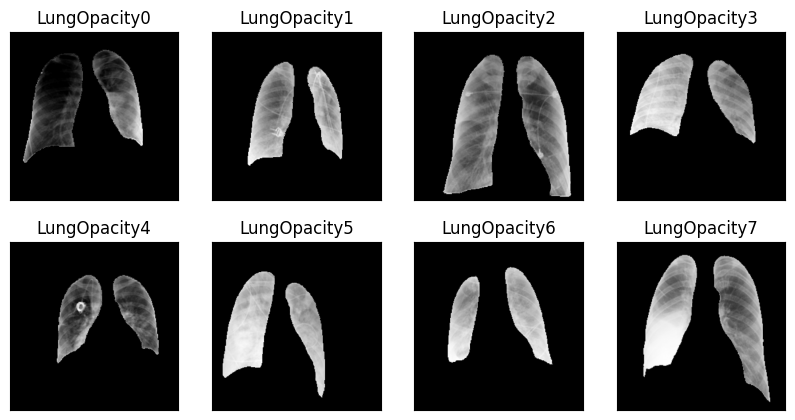

In [ ]:
rows = 2
columns = 4
fig =  plt.figure(figsize = (10,5))

for i in range(0, rows*columns):
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_LungOpacity[:,:,i], cmap='gray');
    plt.xticks([]);
    plt.yticks([]);
    plt.title("LungOpacity"+str(i))


Text(0.5, 1.0, 'mean of all lung opacity images')

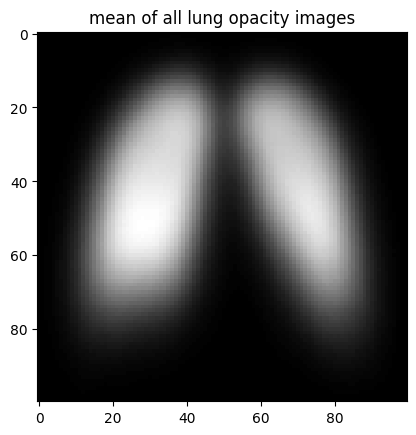

In [ ]:
lungOpacitymean=np.mean(all_small_LungOpacity, axis=2).astype("uint8")
plt.imshow(lungOpacitymean, cmap='gray');
plt.title("mean of all lung opacity images")

Text(0.5, 1.0, 'median of all lung opacity images')

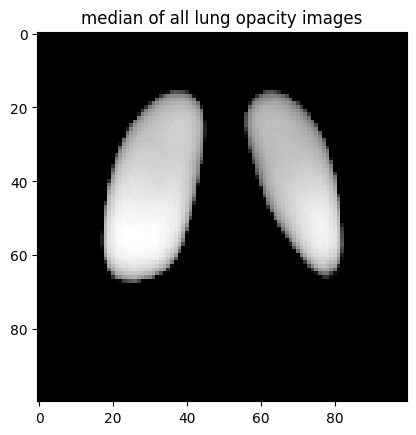

In [ ]:
lungOpacitymedian=np.median(all_small_LungOpacity, axis=2).astype("uint8")
plt.imshow(lungOpacitymedian, cmap='gray');
plt.title("median of all lung opacity images")

In [ ]:
all_lungOpacity_mse=[]
for i in range(0, nb_files_LungOpacity):
    
    diff= mse(lungOpacitymean, all_small_LungOpacity[:,:,i])
    all_lungOpacity_mse.append(diff)

Text(0.5, 1.0, 'mse between each lung opacity image and the mean of all lung opacity images')

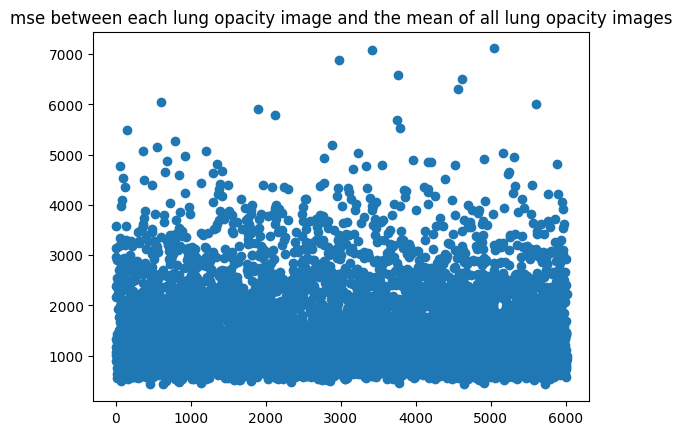

In [ ]:
plt.scatter(range(0, len(all_lungOpacity_mse)), all_lungOpacity_mse)
plt.title("mse between each lung opacity image and the mean of all lung opacity images")

In [ ]:
all_lungOpacity_mse_arr = np.array(all_lungOpacity_mse)
mask = all_lungOpacity_mse_arr > 5000
values_outliers_lungOpacity=np.where(mask)[0]
print("indices:",values_outliers_lungOpacity)

indices: [ 143  357  547  607  795 1199 1900 2125 2879 2970 3230 3415 3749 3766
 3783 4561 4612 5039 5156 5600]


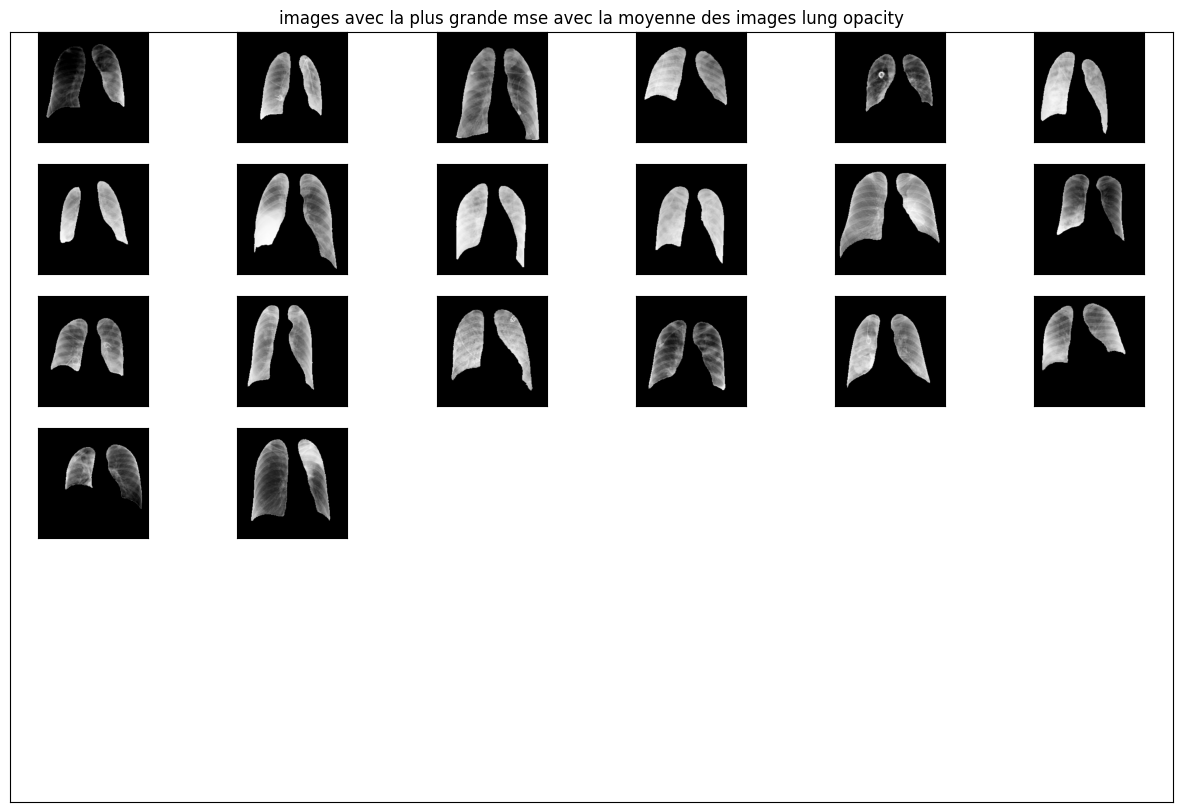

In [ ]:
fig =  plt.figure(figsize = (15,10))
plt.title("images avec la plus grande mse avec la moyenne des images lung opacity")
plt.xticks([]);
plt.yticks([]);
columns = 6
rows = len(values_outliers_lungOpacity)//4+1

for i in range(0, len(values_outliers_lungOpacity)):
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_LungOpacity[:,:,i], cmap='gray');
    plt.xticks([]);
    plt.yticks([]);

In [ ]:
##### fin lung opacity et debut viral pneumonia ####

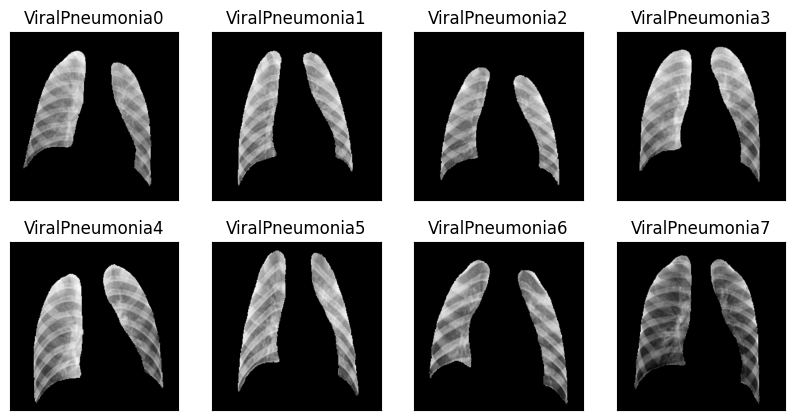

In [ ]:
rows = 2
columns = 4
fig =  plt.figure(figsize = (10,5));

for i in range(0, rows*columns):
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_ViralPneumonia[:,:,i], cmap='gray');
    plt.xticks([]);
    plt.yticks([]);
    plt.title("ViralPneumonia"+str(i));

Text(0.5, 1.0, 'mean of all viral pneumonia images')

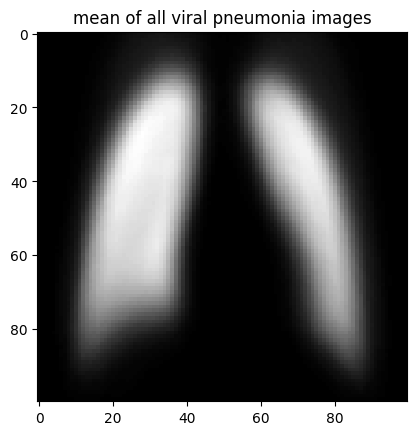

In [ ]:
ViralPneumoniamean=np.mean(all_small_ViralPneumonia, axis=2).astype("uint8")
plt.imshow(ViralPneumoniamean, cmap='gray');
plt.title("mean of all viral pneumonia images")

Text(0.5, 1.0, 'median of all viral pneumonia images')

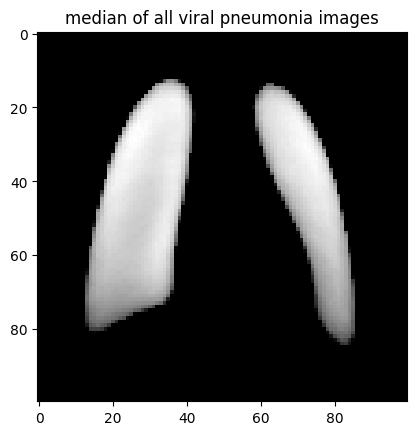

In [ ]:
ViralPneumoniamedian=np.median(all_small_ViralPneumonia, axis=2).astype("uint8")
plt.imshow(ViralPneumoniamedian, cmap='gray');
plt.title("median of all viral pneumonia images")

In [ ]:
all_ViralPneumonia_mse=[]
for i in range(0, nb_files_ViralPneumonia):
    
    diff= mse(ViralPneumoniamean, all_small_ViralPneumonia[:,:,i])
    all_ViralPneumonia_mse.append(diff)

Text(0.5, 1.0, 'mse between each viral pneumonia image and the mean of all viral pneumonia images')

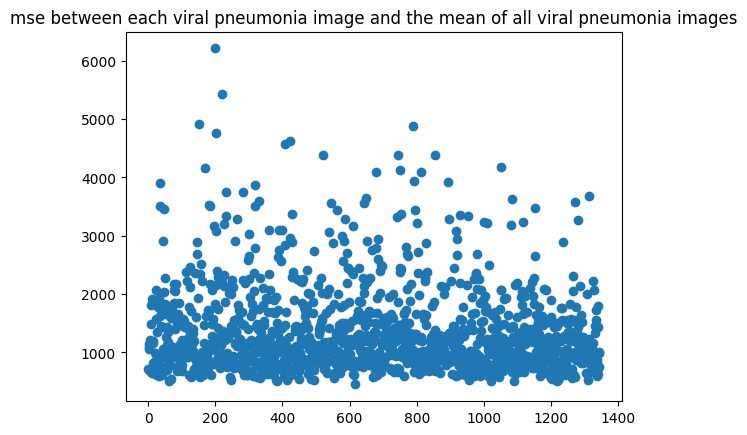

In [ ]:
plt.scatter(range(0, len(all_ViralPneumonia_mse)), all_ViralPneumonia_mse)
plt.title("mse between each viral pneumonia image and the mean of all viral pneumonia images")

In [ ]:
all_ViralPneumonia_mse_arr = np.array(all_ViralPneumonia_mse)
mask = all_ViralPneumonia_mse_arr > 3500
values_outliers_ViralPneumonia=np.where(mask)[0]
print("indices:",values_outliers_ViralPneumonia)

indices: [  34   35  150  169  180  183  200  201  221  233  281  318  319  331
  408  421  521  546  644  650  680  744  749  789  791  814  855  893
 1050 1083 1272 1315]


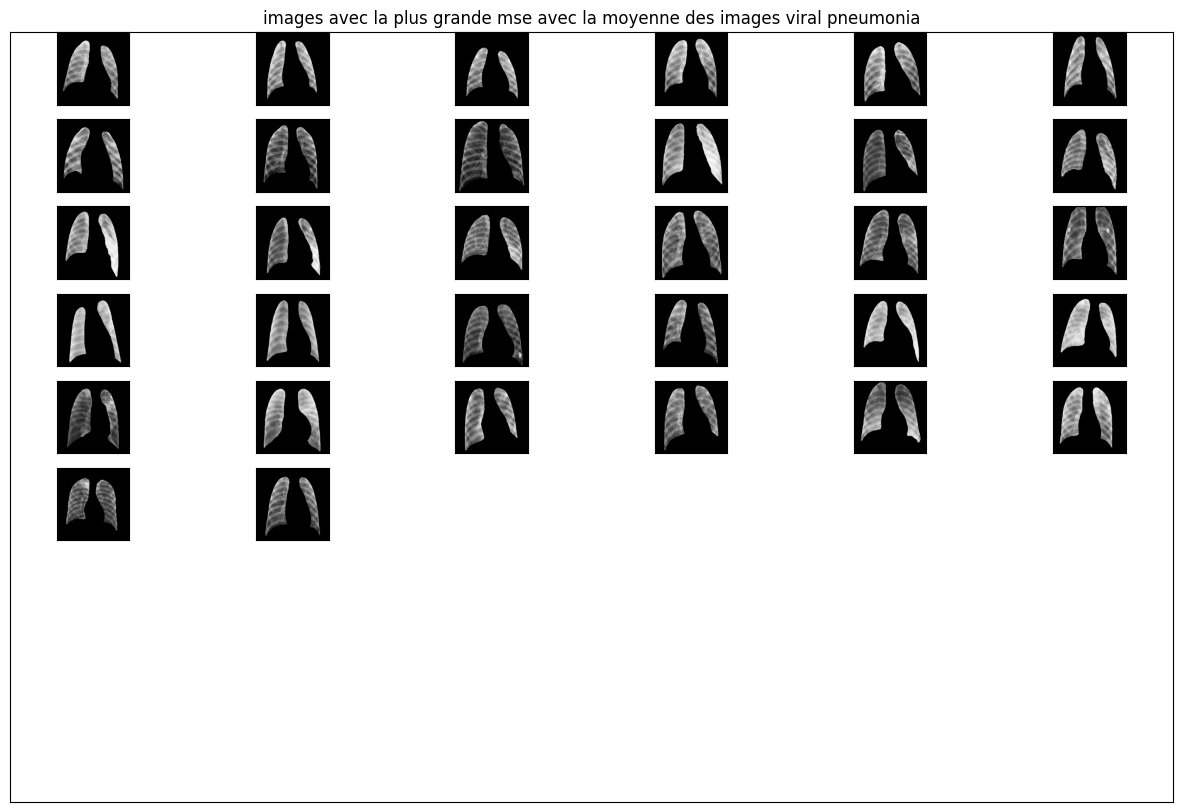

In [ ]:
fig =  plt.figure(figsize = (15,10))
plt.title("images avec la plus grande mse avec la moyenne des images viral pneumonia")
plt.xticks([]);
plt.yticks([]);
columns = 6
rows = len(values_outliers_ViralPneumonia)//4+1

for i in range(0, len(values_outliers_ViralPneumonia)):
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_ViralPneumonia[:,:,i], cmap='gray');
    plt.xticks([]);
    plt.yticks([]);

In [ ]:
# analyse avec traitement d'images

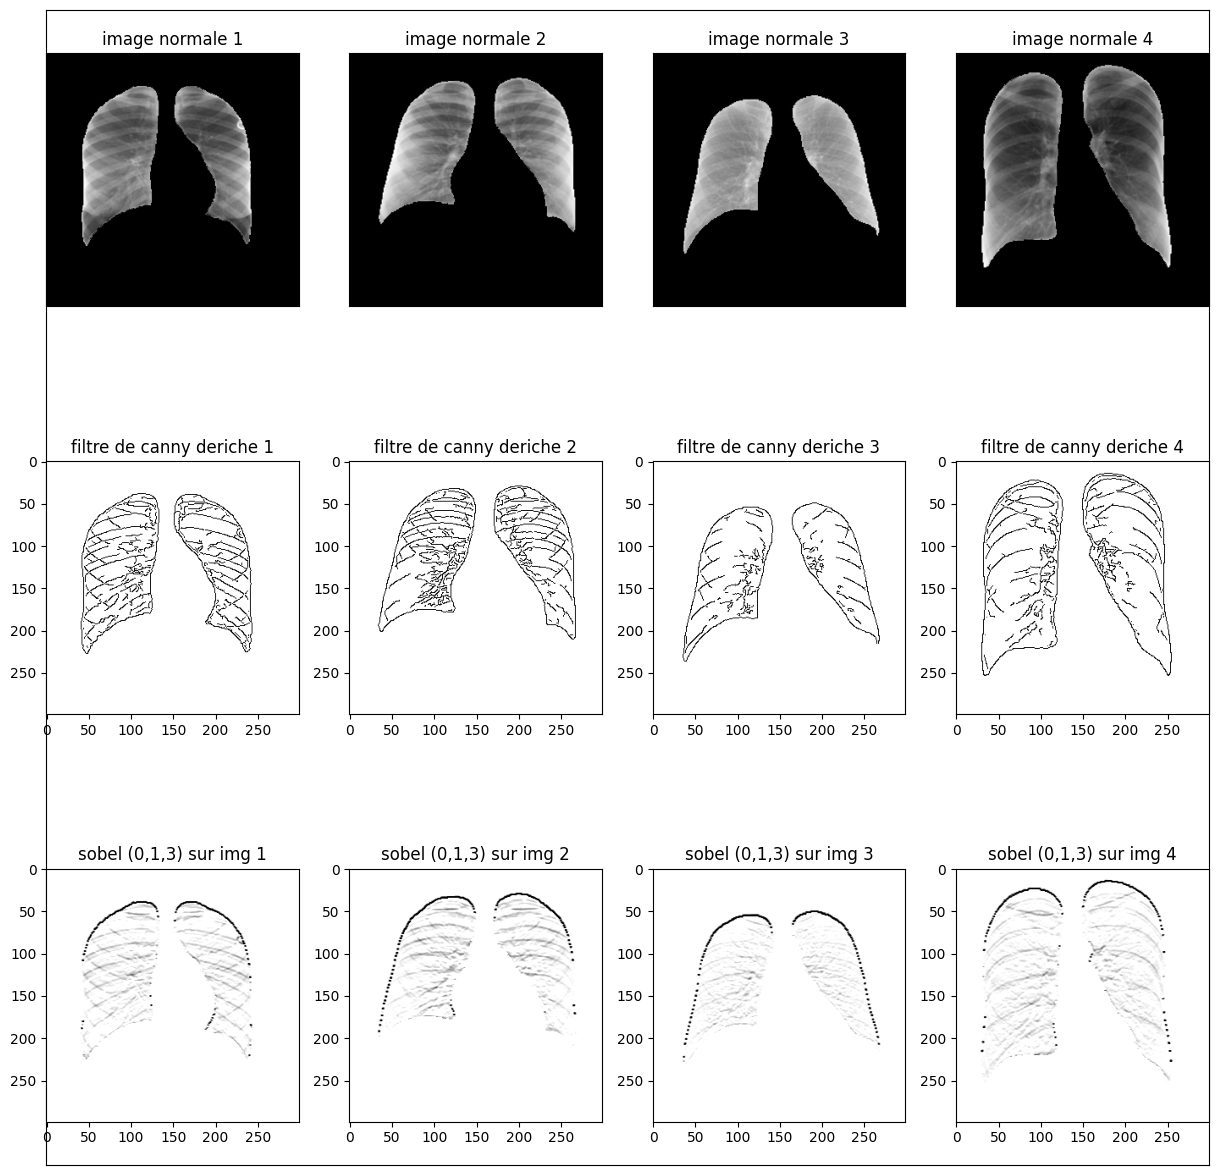

In [ ]:

fig =  plt.figure(figsize = (15,15))
plt.xticks([]);
plt.yticks([]);
columns = 4
rows = 3

for i in range(0, 4):

    img_edges = cv2.Canny(all_img_Normal[:,:,i],50,100)
    img_mask_edges = cv2.Canny(all_masks_Normal[:,:,i],50,100)
    img_edges_minus_masks = cv2.bitwise_not(img_edges,img_mask_edges)
    
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_Normal[:,:,i], cmap='gray');
    plt.title("image normale " + str(i+1))
    plt.xticks([]);
    plt.yticks([]);
    
    fig.add_subplot(rows, columns, i+5)
    plt.imshow(img_edges_minus_masks, cmap='gray');
    plt.title("filtre de canny deriche " + str(i+1))

    fig.add_subplot(rows, columns, i+1+2*columns)
    filteredsobel = cv2.Sobel(all_img_Normal[:,:,i], cv2.CV_8U, 0, 1, ksize = 3)
    filteredsobel = cv2.bitwise_not(filteredsobel,img_mask_edges)
    plt.imshow(filteredsobel, cmap='gray');
    plt.title("sobel (0,1,3) sur img " + str(i+1))

    

    

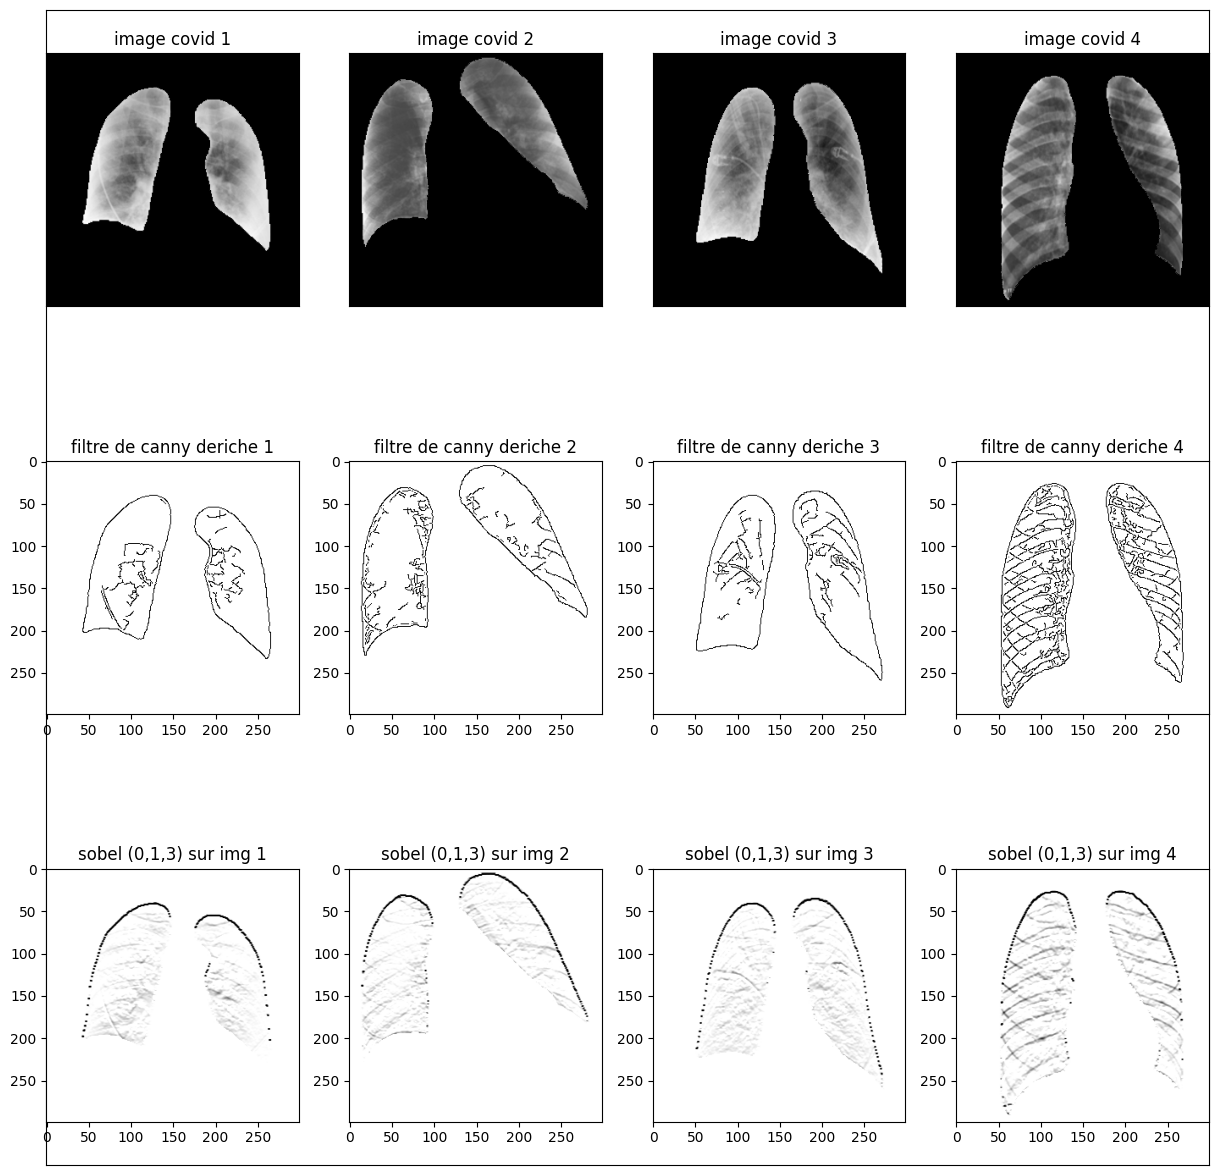

In [ ]:
fig =  plt.figure(figsize = (15,15))
plt.xticks([]);
plt.yticks([]);
columns = 4
rows = 3

for i in range(0, 4):

    img_edges = cv2.Canny(all_img_Covid[:,:,i],50,100)
    img_mask_edges = cv2.Canny(all_masks_Covid[:,:,i],50,100)
    img_edges_minus_masks = cv2.bitwise_not(img_edges,img_mask_edges)
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_Covid[:,:,i], cmap='gray');
    plt.title("image covid " + str(i+1))
    plt.xticks([]);
    plt.yticks([]);
    fig.add_subplot(rows, columns, i+5)
    plt.imshow(img_edges_minus_masks, cmap='gray');
    plt.title("filtre de canny deriche " + str(i+1))

    fig.add_subplot(rows, columns, i+1+2*columns)
    filteredsobel = cv2.Sobel(all_img_Covid[:,:,i], cv2.CV_8U, 0, 1, ksize = 3)
    filteredsobel = cv2.bitwise_not(filteredsobel,img_mask_edges)
    plt.imshow(filteredsobel, cmap='gray');
    plt.title("sobel (0,1,3) sur img " + str(i+1))

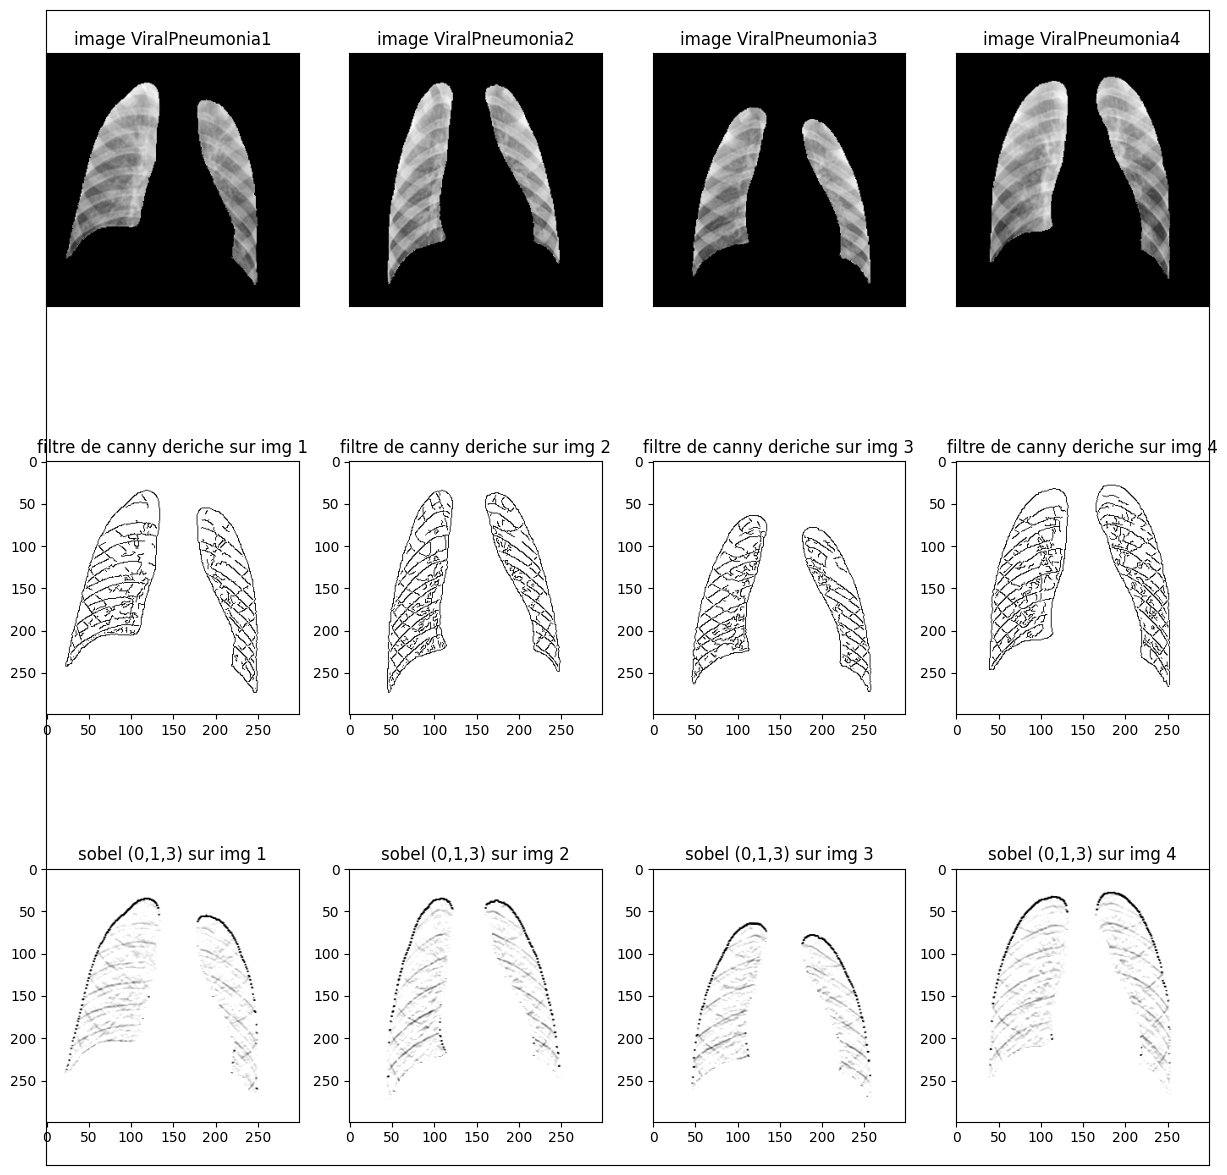

In [ ]:
fig =  plt.figure(figsize = (15,15))
plt.xticks([]);
plt.yticks([]);
columns = 4
rows = 3

for i in range(0, 4):

    img_edges = cv2.Canny(all_img_ViralPneumonia[:,:,i],50,100)
    img_mask_edges = cv2.Canny(all_masks_ViralPneumonia[:,:,i],50,100)
    img_edges_minus_masks = cv2.bitwise_not(img_edges,img_mask_edges)
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_ViralPneumonia[:,:,i], cmap='gray');
    plt.title("image ViralPneumonia" + str(i+1))
    plt.xticks([]);
    plt.yticks([]);
    fig.add_subplot(rows, columns, i+5)
    plt.imshow(img_edges_minus_masks, cmap='gray');
    plt.title("filtre de canny deriche sur img " + str(i+1))

    fig.add_subplot(rows, columns, i+1+2*columns)
    filteredsobel = cv2.Sobel(all_img_ViralPneumonia[:,:,i], cv2.CV_8U, 0, 1, ksize = 3)
    filteredsobel = cv2.bitwise_not(filteredsobel,img_mask_edges)
    plt.imshow(filteredsobel, cmap='gray');
    plt.title("sobel (0,1,3) sur img " + str(i+1))

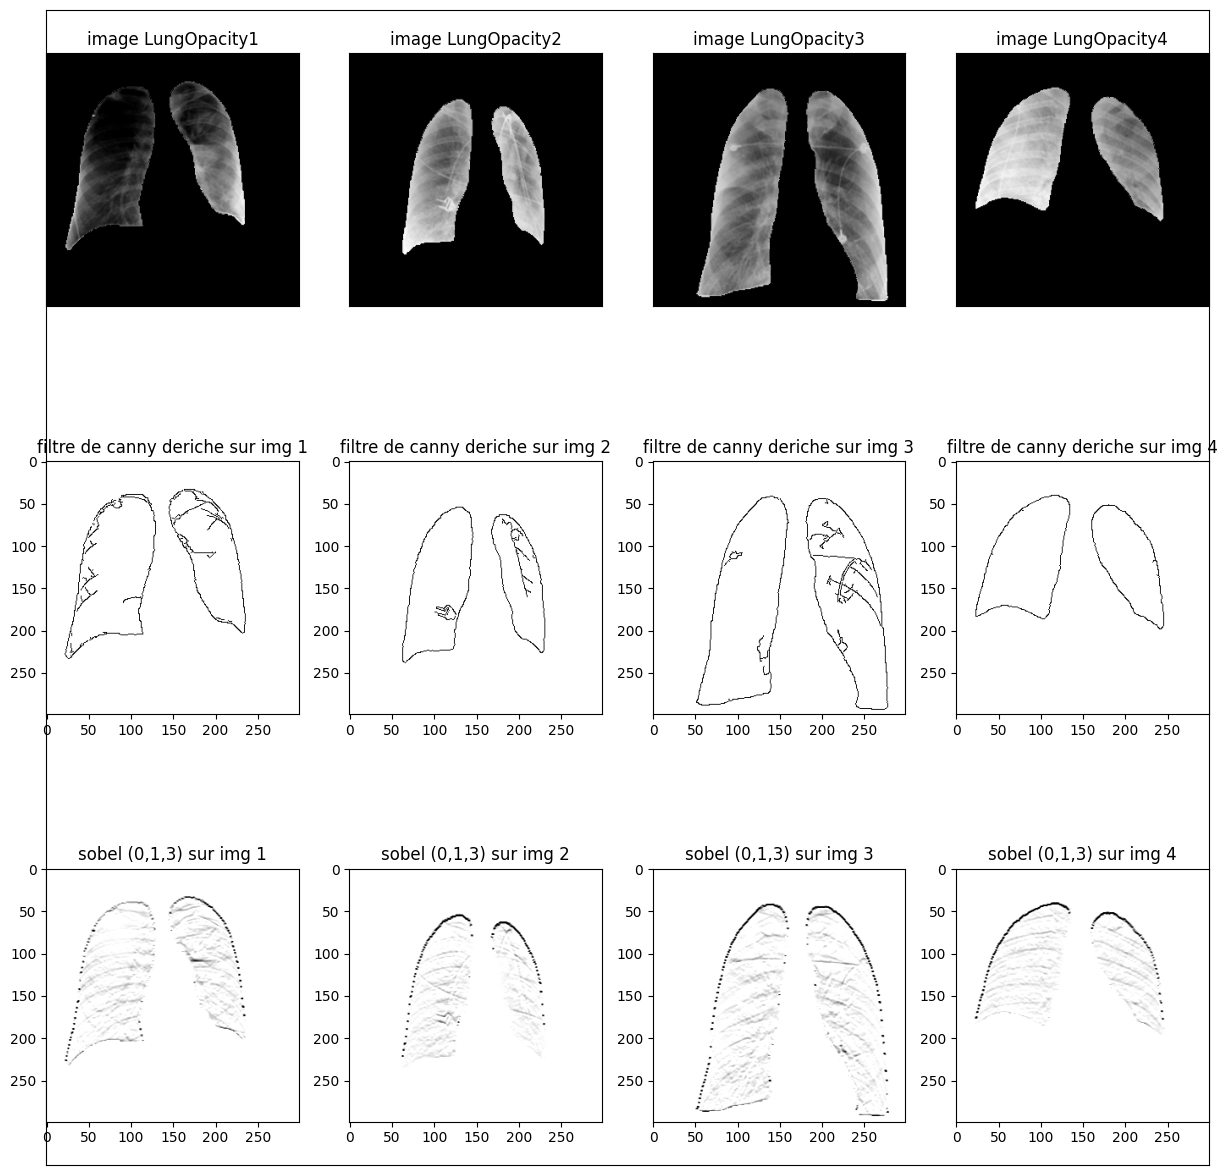

In [ ]:
fig =  plt.figure(figsize = (15,15))
plt.xticks([]);
plt.yticks([]);
columns = 4
rows = 3

for i in range(0, 4):

    img_edges = cv2.Canny(all_img_LungOpacity[:,:,i],50,200)
    img_mask_edges = cv2.Canny(all_masks_LungOpacity[:,:,i],50,200)
    img_edges_minus_masks = cv2.bitwise_not(img_edges,img_mask_edges)
    img_edges_minus_masks_blur = cv2.GaussianBlur(img_edges_minus_masks,(9,9),3,4)
    img_test = cv2.bitwise_and(all_img_LungOpacity[:,:,i],img_edges_minus_masks_blur)

    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_LungOpacity[:,:,i], cmap='gray');
    plt.title("image LungOpacity" + str(i+1))
    plt.xticks([]);
    plt.yticks([]);

    fig.add_subplot(rows, columns, i+1+columns)
    plt.imshow(img_edges_minus_masks, cmap='gray');
    plt.title("filtre de canny deriche sur img " + str(i+1))

    fig.add_subplot(rows, columns, i+1+2*columns)
    filteredsobel = cv2.Sobel(all_img_LungOpacity[:,:,i], cv2.CV_8U, 0, 1, ksize = 3)
    filteredsobel = cv2.bitwise_not(filteredsobel,img_mask_edges)
    plt.imshow(filteredsobel, cmap='gray');
    plt.title("sobel (0,1,3) sur img " + str(i+1))

In [ ]:
# detection des images floues Normal

variance_laplacien_Normal=[]
for i in range(0, nb_files_Normal):

    variance_laplacien_Normal.append(cv2.Laplacian(all_img_Normal_without_mask[:,:,i], cv2.CV_64F).var())

    # detection des images floues Covid

variance_laplacien_Covid=[]
for i in range(0, nb_files_Covid):

    variance_laplacien_Covid.append(cv2.Laplacian(all_img_Covid_without_mask[:,:,i], cv2.CV_64F).var())


# detection des images floues Lung Opacity

variance_laplacien_LungOpacity=[]
for i in range(0, nb_files_LungOpacity):

    variance_laplacien_LungOpacity.append(cv2.Laplacian(all_img_LungOpacity_without_mask[:,:,i], cv2.CV_64F).var())


# detection des images floues Viral Pneumo

variance_laplacien_ViralPneumonia=[]
for i in range(0, nb_files_ViralPneumonia):

    variance_laplacien_ViralPneumonia.append(cv2.Laplacian(all_img_ViralPneumonia_without_mask[:,:,i], cv2.CV_64F).var())



Text(0.5, 1.0, 'variance laplacien Viral Pneumonia = flou ')

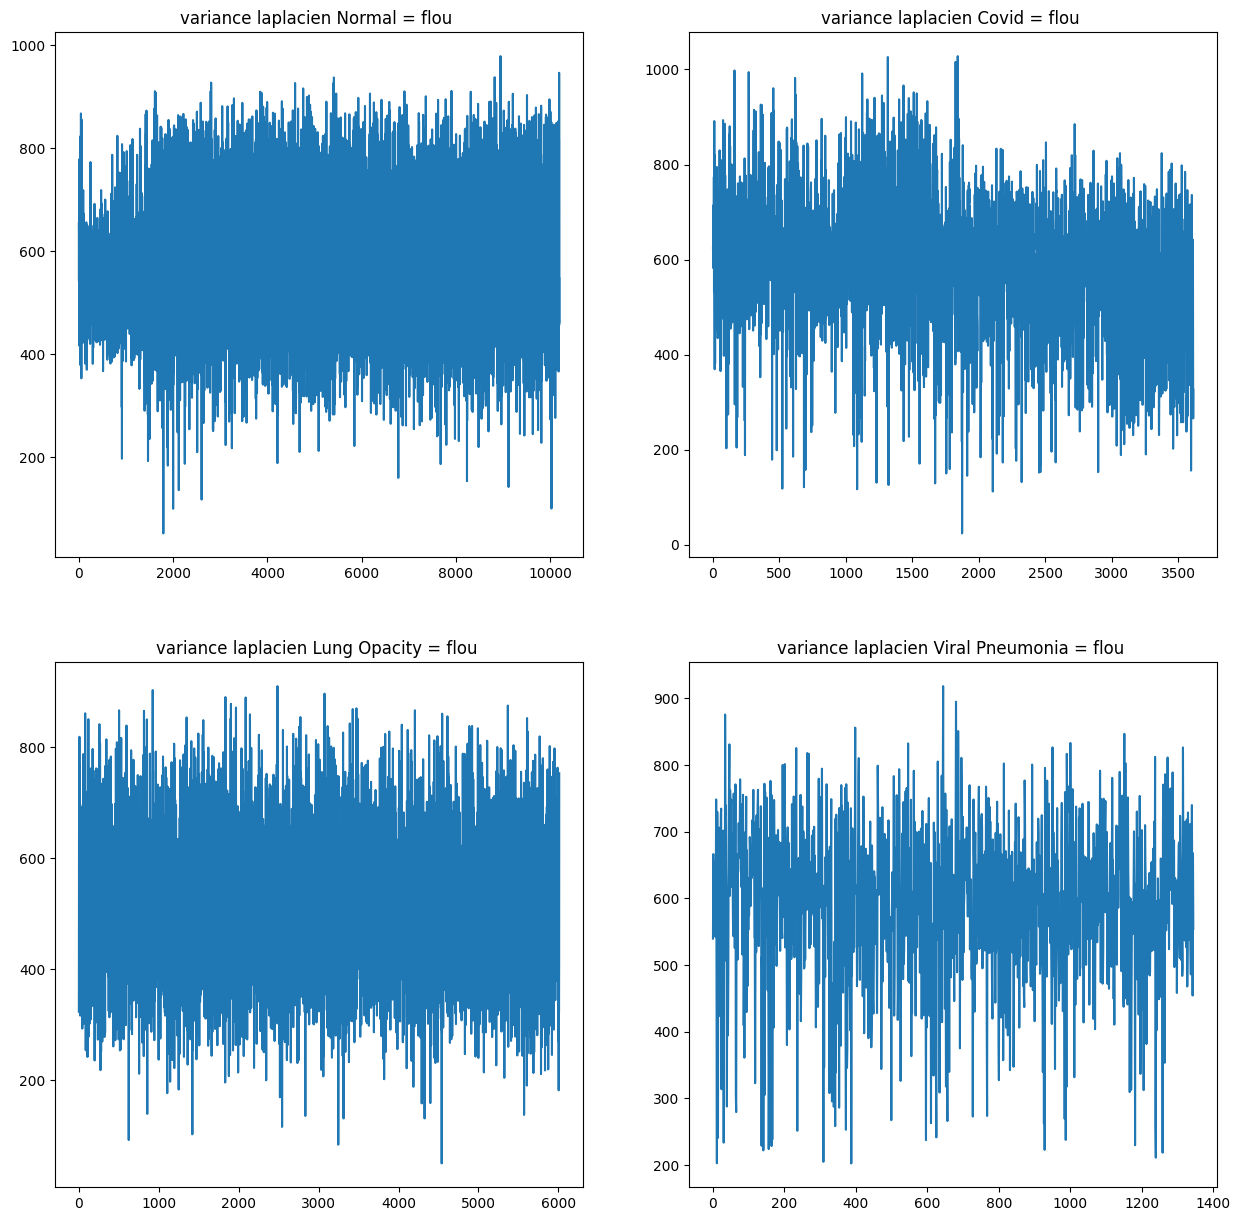

In [ ]:
fig =  plt.figure(figsize = (15,15)) 
plt.subplot(2,2,1)
plt.plot(range(0, nb_files_Normal),variance_laplacien_Normal)
plt.title("variance laplacien Normal = flou ")
plt.subplot(2,2,2)
plt.plot(range(0, nb_files_Covid),variance_laplacien_Covid)
plt.title("variance laplacien Covid = flou ")
plt.subplot(2,2,3)
plt.plot(range(0, nb_files_LungOpacity),variance_laplacien_LungOpacity)
plt.title("variance laplacien Lung Opacity = flou ")
plt.subplot(2,2,4)
plt.plot(range(0, nb_files_ViralPneumonia),variance_laplacien_ViralPneumonia)
plt.title("variance laplacien Viral Pneumonia = flou ")

In [ ]:
variance_laplacien_normal_arr = np.array(variance_laplacien_Normal)
maskNormal = variance_laplacien_normal_arr < 200
outliers_variance_laplacien_normal=np.where(maskNormal)[0]
print("indices flous cas normaux :",outliers_variance_laplacien_normal+1)

variance_laplacien_Covid_arr = np.array(variance_laplacien_Covid)
maskCovid = variance_laplacien_Covid_arr < 150
outliers_variance_laplacien_Covid=np.where(maskCovid)[0]
print("indices flous cas covid :",outliers_variance_laplacien_Covid+1)

variance_laplacien_LungOpacity_arr = np.array(variance_laplacien_LungOpacity)
maskLungOpacity = variance_laplacien_LungOpacity_arr < 150
outliers_variance_laplacien_LungOpacity=np.where(maskLungOpacity)[0]
print("indices flous cas Lung Opacity :",outliers_variance_laplacien_LungOpacity+1)

variance_laplacien_ViralPneumonia_arr = np.array(variance_laplacien_ViralPneumonia)
maskViralPneumonia = variance_laplacien_ViralPneumonia_arr < 230
outliers_variance_laplacien_ViralPneumonia=np.where(maskViralPneumonia)[0]
print("indices flous cas Viral Pneumonia:",outliers_variance_laplacien_ViralPneumonia+1)

indices flous cas normaux : [  915  1468  1793  1888  2001  2121  2248  2605  4213  6778  7676  8235
  9117 10027]
indices flous cas covid : [ 523  686 1086 1232 1322 1673 1757 1876 1914 2107 2324]
indices flous cas Lung Opacity : [ 625  857 1421 2544 2835 3247 3313 4327 4541 5572]
indices flous cas Viral Pneumonia: [  12  137  142  157  165  310  388  929 1182 1240 1259]


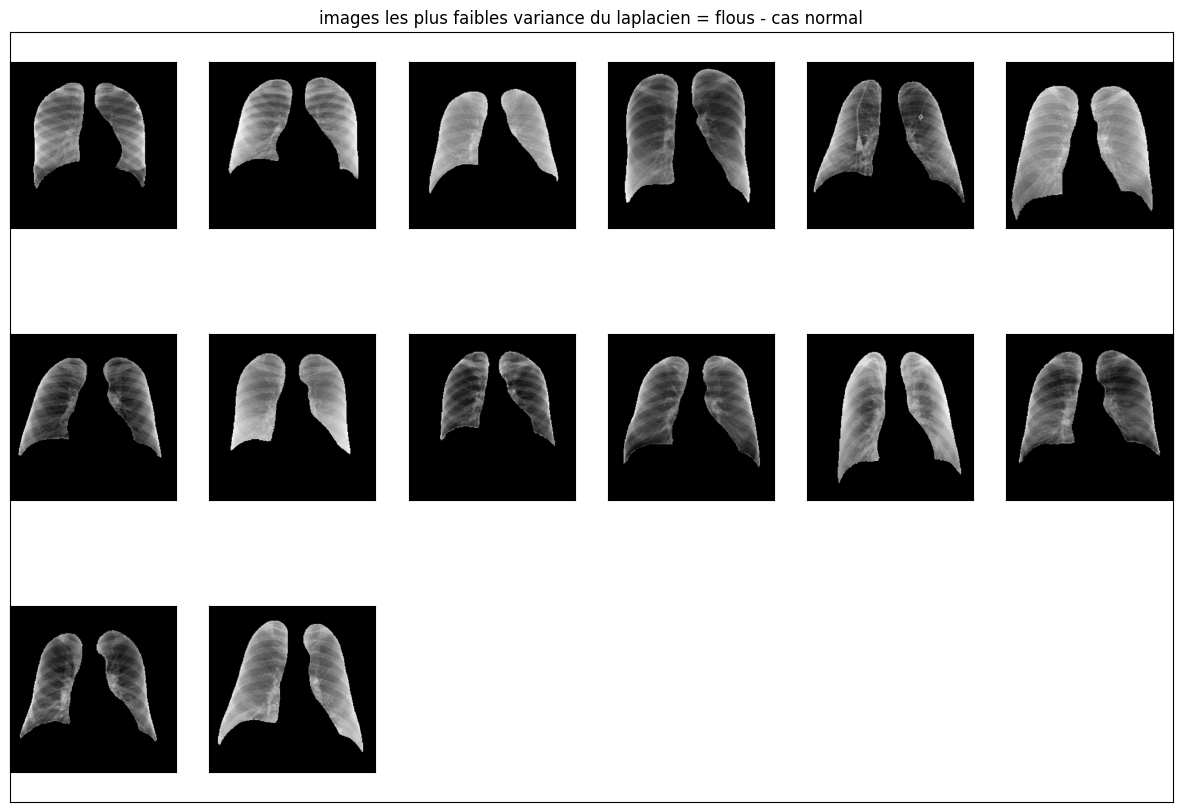

In [ ]:

fig =  plt.figure(figsize = (15,10))

#  normal
plt.title("images les plus faibles variance du laplacien = flous - cas normal")
plt.xticks([]);
plt.yticks([]);
columns = 6
rows = np.ceil(len(outliers_variance_laplacien_normal)//columns+1)

for i in range(0, len(outliers_variance_laplacien_normal)):
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_Normal_without_mask[:,:,i], cmap='gray');
    plt.xticks([]);
    plt.yticks([]);





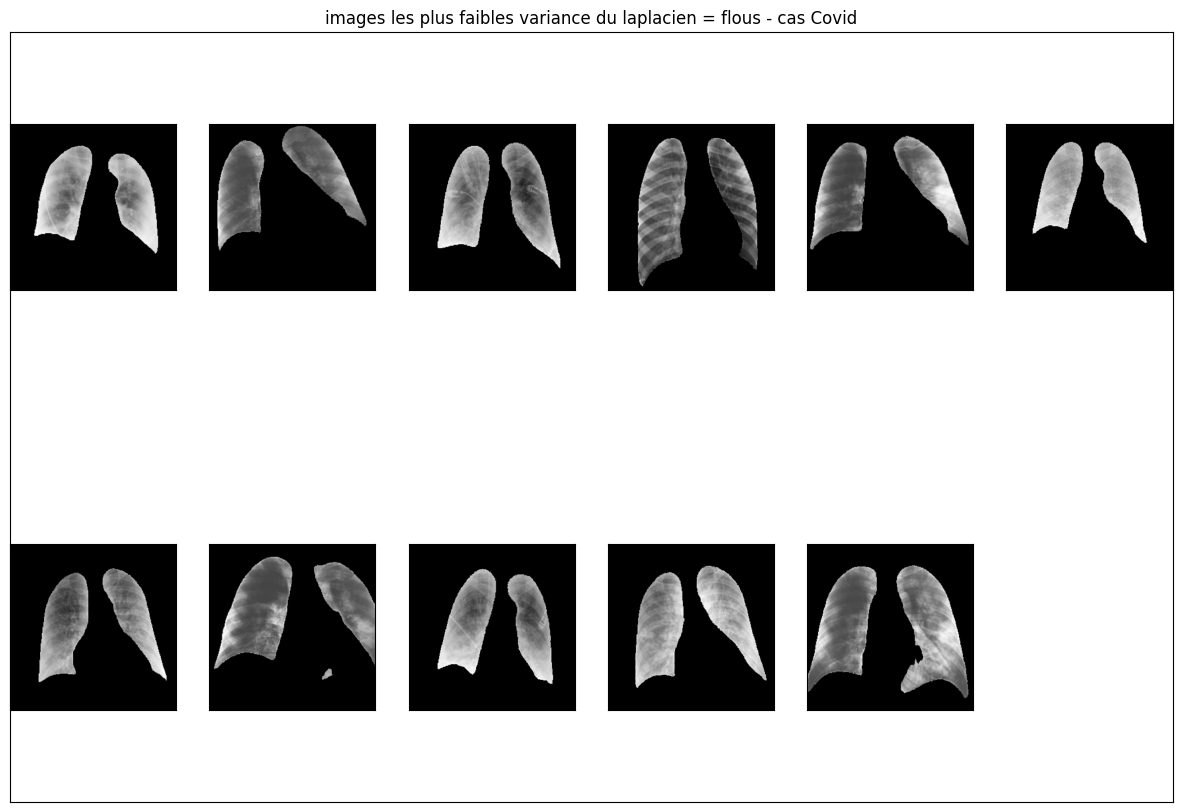

In [ ]:
#  covid
fig =  plt.figure(figsize = (15,10))
plt.title("images les plus faibles variance du laplacien = flous - cas Covid")
plt.xticks([]);
plt.yticks([]);
columns = 6
rows = np.ceil(len(outliers_variance_laplacien_Covid)//columns+1)

for i in range(0, len(outliers_variance_laplacien_Covid)):
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_Covid_without_mask[:,:,i], cmap='gray');
    plt.xticks([]);
    plt.yticks([]);

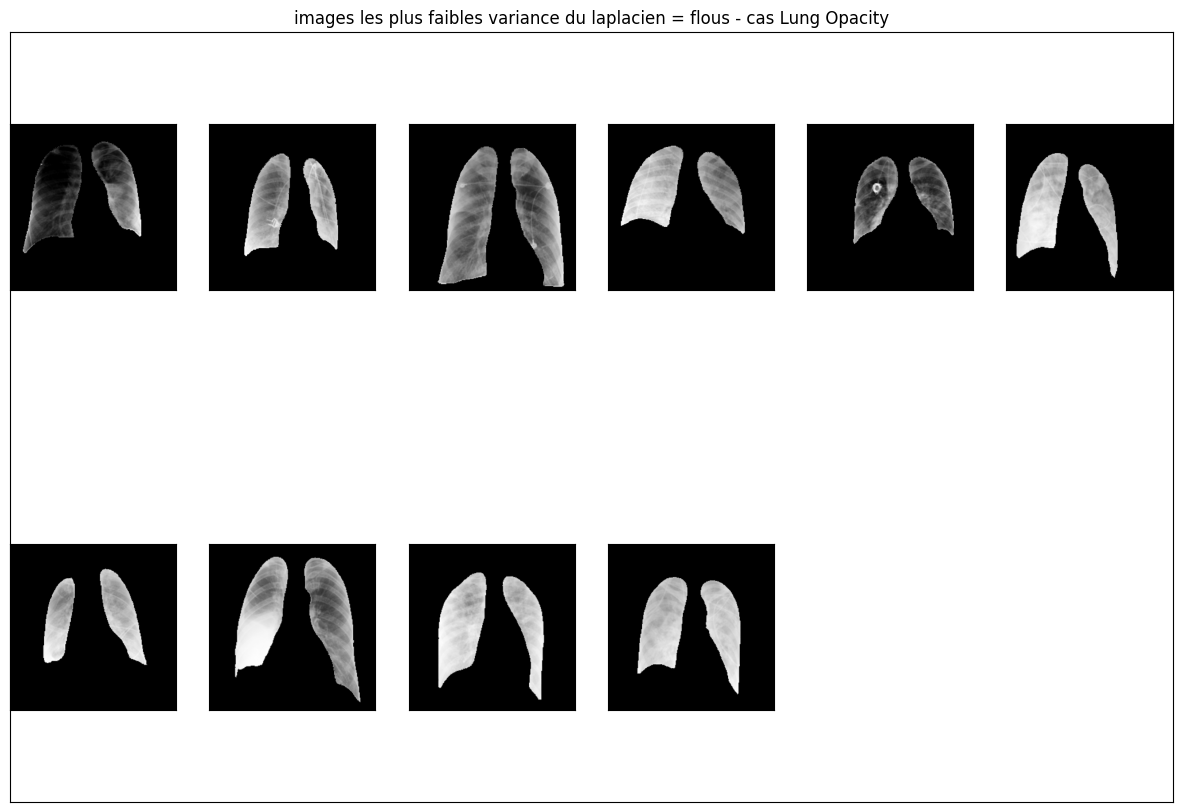

In [ ]:
# LungOpacity
fig =  plt.figure(figsize = (15,10))
plt.title("images les plus faibles variance du laplacien = flous - cas Lung Opacity")
plt.xticks([]);
plt.yticks([]);
columns = 6
rows = np.ceil(len(outliers_variance_laplacien_LungOpacity)//columns+1)

for i in range(0, len(outliers_variance_laplacien_LungOpacity)):
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_LungOpacity_without_mask[:,:,i], cmap='gray');
    plt.xticks([]);
    plt.yticks([]);


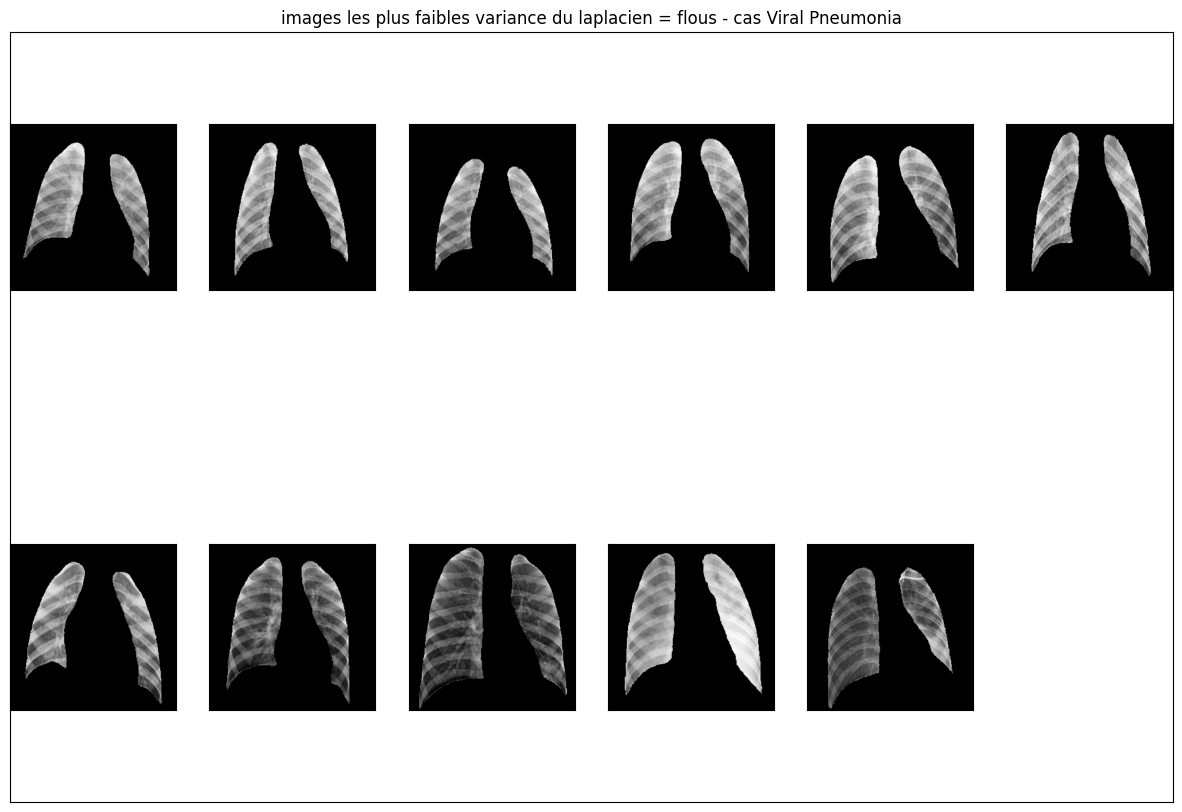

In [ ]:
# Viral Pneumonia
fig =  plt.figure(figsize = (15,10))
plt.title("images les plus faibles variance du laplacien = flous - cas Viral Pneumonia")
plt.xticks([]);
plt.yticks([]);
columns = 6
rows = np.ceil(len(outliers_variance_laplacien_ViralPneumonia)//columns+1)

for i in range(0, len(outliers_variance_laplacien_ViralPneumonia)):
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(all_img_ViralPneumonia_without_mask[:,:,i], cmap='gray');
    plt.xticks([]);
    plt.yticks([]);